In [1]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import random
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qiskit import transpile
from qiskit.circuit import Parameter,ParameterExpression
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit.converters import circuit_to_dag, dag_to_circuit

import sys
sys.path.append("../")
from clapton.clapton import claptonize
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit , multi_angle_qaoa_plus_circuit
from testing_scripts.graphs_utils import generate_random_complete_graph,generate_k_regular_graph,compute_optimal_max_cut,build_max_cut_paulis
from testing_scripts.energy_utils import evaluate_energy

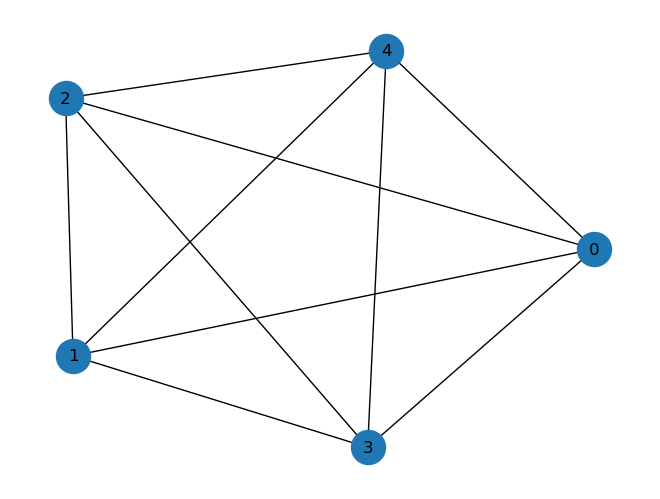

In [2]:
n = 5

k=3
# G = generate_k_regular_graph(num_vertices=n, k=k, weighted=True,seed=True)

G=generate_random_complete_graph(num_vertices=n, weighted=True, seed=True)
draw_graph(G, node_size=600, with_labels=True)

In [3]:
# Optimal Maxcut Calculation 
optimal_max_cut_val = compute_optimal_max_cut(G)
print(f"Optimal Max Cut Value : {optimal_max_cut_val}")

Optimal Max Cut Value : 43


In [4]:
max_cut_paulis = build_max_cut_paulis(G)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)
paulis,coeffs = cost_hamiltonian.paulis.to_labels(),cost_hamiltonian.coeffs.real

Cost Function Hamiltonian: SparsePauliOp(['IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[7.+0.j, 7.+0.j, 1.+0.j, 5.+0.j, 9.+0.j, 8.+0.j, 7.+0.j, 5.+0.j, 8.+0.j,
 6.+0.j])


In [5]:
# Need to reverse the Paulis for stim adapation 
reversed_paulis = [p[::-1] for p in paulis]
print(reversed_paulis)

['ZZIII', 'ZIZII', 'ZIIZI', 'ZIIIZ', 'IZZII', 'IZIZI', 'IZIIZ', 'IIZZI', 'IIZIZ', 'IIIZZ']


In [ ]:
reps =2 


ma_qaoa_plus_ansatz= multi_angle_qaoa_plus_circuit(n,G,reps) 

In [7]:
# ma_qaoa_plus_ansatz.draw('mpl')


In [8]:
# Transform qiskit circ. to stim.
modified_circ = modify_circuit(ma_qaoa_plus_ansatz)
pcirc = transform_to_allowed_gates(modified_circ)

stim_circ = qiskit_to_stim(pcirc)
stim_circ.stim_circuit().diagram()

/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/transpiler/passmanager.py:70: DeprecationWarning: The property ``qiskit.dagcircuit.dagcircuit.DAGCircuit.duration`` is deprecated as of qiskit 1.3.0. It will be removed in Qiskit 2.0.0.
  out_program = dag_to_circuit(passmanager_ir, copy_operations=False)
/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/transpiler/passmanager.py:70: DeprecationWarning: The property ``qiskit.dagcircuit.dagcircuit.DAGCircuit.unit`` is deprecated as of qiskit 1.3.0. It will be removed in Qiskit 2.0.0.
  out_program = dag_to_circuit(passmanager_ir, copy_operations=False)
/global/u1/d/dhanvib/development/QAOA/playground_scripts/../clapton/circuit_manipulation.py:211: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate = in

q0: -H-@---@-@---@-------@---@-------------@---@-S-SQRT_X-I-SQRT_X-Z-------------------------@---@-SQRT_X-I-SQRT_X-S-------------------------------------------------------------------------------------------------------------------------------------------------------------------
       |   | |   |       |   |             |   |                                             |   |
q1: -H-X-I-X-|---|-@---@-|---|-@---@-------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-X-I-X-------------------------------------------@---@-S-SQRT_X-I-SQRT_X-S-----------------------------------------------------------------------------------------------------------------
             |   | |   | |   | |   |       |   |                   |   |                                                                     |   |
q2: -------H-X-I-X-X-I-X-|---|-|---|-@---@-|---|-------------------|---|-------------------------------------------@---@-S-SQRT_X-I-SQRT_X-S-X-I-X---------------------------------------------@---@-S-SQRT_X-I-SQRT_X-S---------------------------------------------------------------
                         |   | |   | |   | |   |                   |   |                                           |   |                                                                       |   |
q3: -------------------H-X-I-X-X-I-X-X-I-X-|---|-------------------|---|-------------------------------------------|---|---------------------------------------------@---@-S-SQRT_X-I-SQRT_X-S-X-I-X---------------------------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------
                                           |   |                   |   |                                           |   |                                             |   |                                                                 |   |
q4: -------------------------------------H-X-I-X-------------------X-I-X-------------------------------------------X-I-X---------------------------------------------X-I-X---------------------------------------------S-SQRT_X-I-SQRT_X-S-X-I-X-------------------S-SQRT_X-I-SQRT_X-S-

In [9]:
ks_best, _, energy_best = claptonize(
    reversed_paulis,    #to respect stim ordering for hamiltonian
    coeffs,
    stim_circ,
    n_proc=4,           # total number of processes in parallel
    n_starts=4,         # number of random genetic algorithm starts in parallel
    n_rounds=1,         # number of budget rounds, if None it will terminate itself
    callback=print,     # callback for internal parameter (#iteration, energies, ks) processing
    budget=10          # budget per genetic algorithm instance
)

STARTING ROUND 0


started GA at id 1 with 1 procs

started GA at id 2 with 1 procs
GA parameters used for this experiment:
  num_generations=10
  num_parents_mating=20
  population_size=100
  num_genes=24
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5started GA at id None with 1 procs

GA parameters used for this experiment:
  num_generations=10
  num_parents_mating=20
  population_size=100
  num_genes=24
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5


started GA at id 3 with 1 procs

GA parameters used for this experiment:
  num_generations=10
  num_parents_mating=20
  population_size=100
  num_genes=24
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=ada

In [10]:
energy_best

np.float64(-22.0)

In [11]:
ma_qaoa_plus_ansatz.num_parameters

24